<a href="https://colab.research.google.com/github/chavi15/Fruits-and-Vegetables-freshness-/blob/main/RestNet50_EfficientNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import kagglehub

In [3]:
DATA_DIR = kagglehub.dataset_download("muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten")

print("Path to dataset files:", DATA_DIR)
image_paths = []
labels = []

dataset_folder_name = os.listdir(DATA_DIR)[0]
dataset_inner_path = os.path.join(DATA_DIR, dataset_folder_name)

for category_name in os.listdir(dataset_inner_path):
    category_dir = os.path.join(dataset_inner_path, category_name)
    if os.path.isdir(category_dir):
        for img_file_name in os.listdir(category_dir):
            full_image_path = os.path.join(category_dir, img_file_name)
            if os.path.isfile(full_image_path):
                image_paths.append(full_image_path)
                labels.append(category_name)

df = pd.DataFrame({
    "path": image_paths,
    "label": labels
})

df.head()

100%|██████████| 4.77G/4.77G [00:42<00:00, 121MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten/versions/1


,path,label
0,/root/.cache/kagglehub/datasets/muhammad0subha...,Strawberry__Rotten
1,/root/.cache/kagglehub/datasets/muhammad0subha...,Strawberry__Rotten
2,/root/.cache/kagglehub/datasets/muhammad0subha...,Strawberry__Rotten
3,/root/.cache/kagglehub/datasets/muhammad0subha...,Strawberry__Rotten
4,/root/.cache/kagglehub/datasets/muhammad0subha...,Strawberry__Rotten


In [4]:
print("Total images:", len(df))
df['label'].value_counts()

Total images: 29291


,count
label,
Apple__Rotten,2930
Banana__Rotten,2800
Apple__Healthy,2438
Mango__Rotten,2247
Orange__Rotten,2186
Orange__Healthy,2075
Banana__Healthy,2000
Mango__Healthy,1813
Strawberry__Healthy,1603


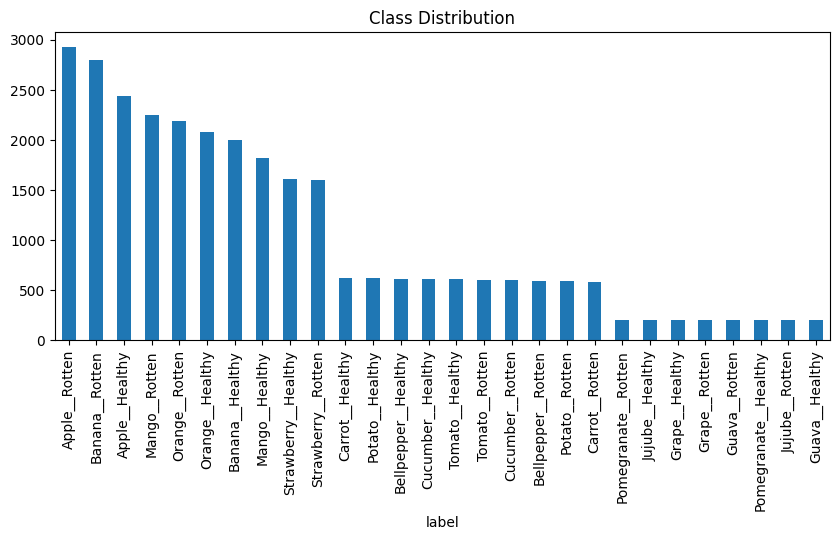

In [5]:
df['label'].value_counts().plot(kind='bar', figsize=(10,4))
plt.title("Class Distribution")
plt.show()

In [6]:
df['status'] = df['label'].apply(
    lambda x: 'Healthy' if 'Healthy' in x else 'Rotten'
)

df['status'].value_counts()

,count
status,
Rotten,15504
Healthy,13787


In [7]:
sizes = []

for p in df['path'][:1000]:
    img = Image.open(p)
    sizes.append(img.size)

sizes = np.array(sizes)

print("Min size:", sizes.min(axis=0))
print("Max size:", sizes.max(axis=0))

Min size: [100 100]
Max size: [4160 4160]


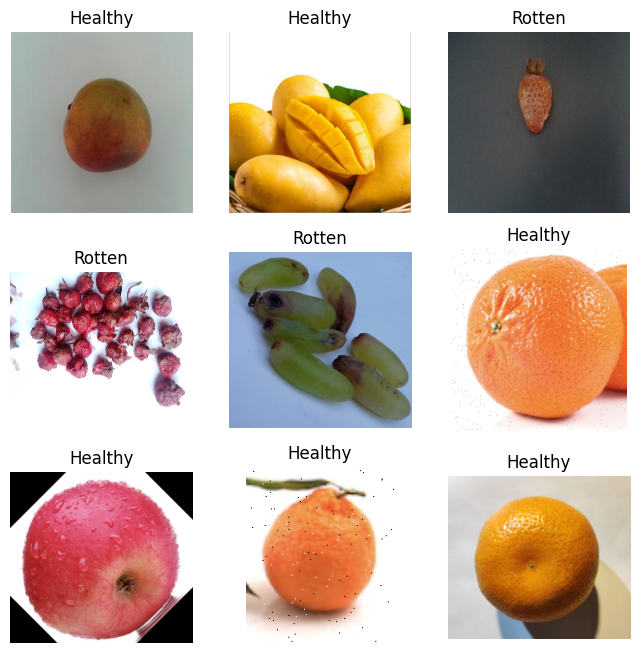

In [8]:
sample = df.sample(9)

plt.figure(figsize=(8,8))
for i, row in enumerate(sample.itertuples()):
    plt.subplot(3,3,i+1)
    img = Image.open(row.path)
    plt.imshow(img)
    plt.title(row.status)
    plt.axis('off')
plt.show()

In [9]:
bad_images = []

for p in df['path']:
    try:
        Image.open(p).verify()
    except:
        bad_images.append(p)

print("Corrupted images:", len(bad_images))

Corrupted images: 0


In [10]:
df = df[~df['path'].isin(bad_images)]


In [11]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['status'],
    random_state=42
)


In [12]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label


In [13]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_inner_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=16,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_inner_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=16,
    label_mode="int"
)





Found 29277 files belonging to 28 classes.
Using 23422 files for training.
Found 29277 files belonging to 28 classes.
Using 5855 files for validation.


In [14]:
class_names = train_ds.class_names
print(class_names)


['Apple__Healthy', 'Apple__Rotten', 'Banana__Healthy', 'Banana__Rotten', 'Bellpepper__Healthy', 'Bellpepper__Rotten', 'Carrot__Healthy', 'Carrot__Rotten', 'Cucumber__Healthy', 'Cucumber__Rotten', 'Grape__Healthy', 'Grape__Rotten', 'Guava__Healthy', 'Guava__Rotten', 'Jujube__Healthy', 'Jujube__Rotten', 'Mango__Healthy', 'Mango__Rotten', 'Orange__Healthy', 'Orange__Rotten', 'Pomegranate__Healthy', 'Pomegranate__Rotten', 'Potato__Healthy', 'Potato__Rotten', 'Strawberry__Healthy', 'Strawberry__Rotten', 'Tomato__Healthy', 'Tomato__Rotten']


In [15]:
def preprocess(images, labels):
    images = tf.image.convert_image_dtype(images, tf.float32)

    labels = tf.cast(labels, tf.int32)
    labels_str = tf.gather(class_names, labels)

    y = tf.cast(
        tf.strings.regex_full_match(labels_str, ".*Rotten.*"),
        tf.float32
    )

    y = tf.expand_dims(y, axis=-1)
    return images, y




In [16]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .apply(tf.data.experimental.ignore_errors())
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .apply(tf.data.experimental.ignore_errors())
    .prefetch(AUTOTUNE)
)



Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


In [17]:
for x, y in train_ds.take(1):
    print(x.shape)
    print(y[:10])



(16, 224, 224, 3)
tf.Tensor(
[[1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [1.]], shape=(10, 1), dtype=float32)


In [18]:
for _, y in train_ds.take(1):
    print(y.shape, y.dtype)


(16, 1) <dtype: 'float32'>


In [19]:
y_train = train_df['status'].map({'Healthy':0, 'Rotten':1}).values

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
class_weights


{0: np.float64(1.0622903255054856), 1: np.float64(0.9446101749576715)}

In [20]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])


In [21]:
base_model = tf.keras.applications.EfficientNetB2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False


31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [22]:
inputs = tf.keras.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)


In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [24]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
]


In [25]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weights
)


Epoch 1/20
   1461/Unknown 145s 86ms/step - accuracy: 0.8925 - loss: 0.2826

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1461/1461 ━━━━━━━━━━━━━━━━━━━━ 182s 112ms/step - accuracy: 0.8925 - loss: 0.2826 - val_accuracy: 0.9561 - val_loss: 0.1228
Epoch 2/20
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 156s 107ms/step - accuracy: 0.9450 - loss: 0.1398 - val_accuracy: 0.9657 - val_loss: 0.0942
Epoch 3/20
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 150s 102ms/step - accuracy: 0.9590 - loss: 0.1066 - val_accuracy: 0.9785 - val_loss: 0.0665
Epoch 4/20
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 149s 102ms/step - accuracy: 0.9637 - loss: 0.0963 - val_accuracy: 0.9790 - val_loss: 0.0619
Epoch 5/20
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 151s 104ms/step - accuracy: 0.9645 - loss: 0.0899 - val_accuracy: 0.9819 - val_loss: 0.0565
Epoch 6/20
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 150s 103ms/step - accuracy: 0.9681 - loss: 0.0783 - val_accuracy: 0.9814 - val_loss: 0.0558
Epoch 7/20
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 148s 101ms/step - accuracy: 0.9752 - loss: 0.0685 - val_accuracy: 0.9793 - val_loss: 0.0609
Epoch 8/20
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 148s 101ms/step - accuracy: 0.9

In [26]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False


In [27]:
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weights
)


Epoch 1/10
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 149s 102ms/step - accuracy: 0.9829 - loss: 0.0483 - val_accuracy: 0.9841 - val_loss: 0.0446
Epoch 2/10
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 146s 100ms/step - accuracy: 0.9816 - loss: 0.0499 - val_accuracy: 0.9862 - val_loss: 0.0460
Epoch 3/10
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 147s 100ms/step - accuracy: 0.9827 - loss: 0.0476 - val_accuracy: 0.9870 - val_loss: 0.0443
Epoch 4/10
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 147s 100ms/step - accuracy: 0.9819 - loss: 0.0536 - val_accuracy: 0.9872 - val_loss: 0.0436
Epoch 5/10
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 202s 139ms/step - accuracy: 0.9848 - loss: 0.0480 - val_accuracy: 0.9848 - val_loss: 0.0520
Epoch 6/10
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 206s 100ms/step - accuracy: 0.9836 - loss: 0.0472 - val_accuracy: 0.9843 - val_loss: 0.0468
Epoch 7/10
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 149s 102ms/step - accuracy: 0.9831 - loss: 0.0480 - val_accuracy: 0.9855 - val_loss: 0.0489


In [28]:
y_true = []
y_pred = []
y_prob = []

for x_batch, y_batch in val_ds:
    preds = model.predict(x_batch, verbose=0)

    y_true.extend(y_batch.numpy().reshape(-1))
    y_prob.extend(preds.reshape(-1))
    y_pred.extend((preds > 0.5).astype(int).reshape(-1))

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = np.array(y_pred)



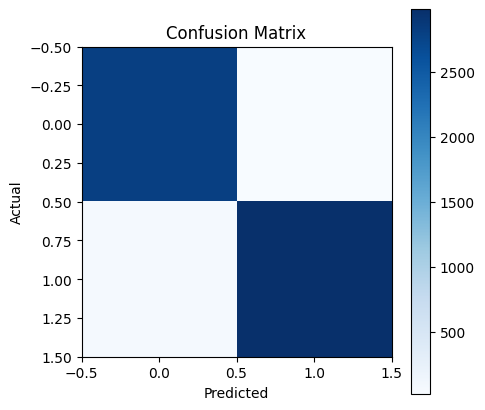

In [29]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


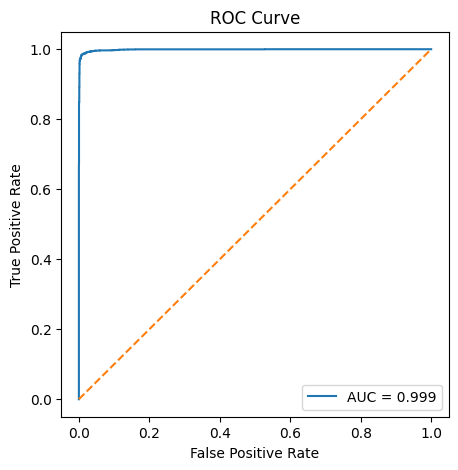

In [30]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [31]:
import numpy as np
from sklearn.metrics import roc_curve, auc

def compute_roc_auc(model, dataset):
    y_true = []
    y_prob = []

    for x_batch, y_batch in dataset:
        probs = model.predict(x_batch, verbose=0)

        y_true.extend(y_batch.numpy().reshape(-1))
        y_prob.extend(probs.reshape(-1))

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    return roc_auc, fpr, tpr


In [32]:
train_auc, train_fpr, train_tpr = compute_roc_auc(model, train_ds)
val_auc, val_fpr, val_tpr = compute_roc_auc(model, val_ds)

print(f"Train ROC-AUC: {train_auc:.4f}")
print(f"Validation ROC-AUC: {val_auc:.4f}")


Train ROC-AUC: 0.9999
Validation ROC-AUC: 0.9988


ResNet50 model

In [33]:
def build_resnet50():
    base_model = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(224,224,3)
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(224,224,3))
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs, outputs)
    return model, base_model


In [34]:

LR_HEAD = 1e-3
LR_FINE = 1e-5


EPOCHS_HEAD = 10
EPOCHS_FINE = 10


In [35]:
resnet50, resnet50_base = build_resnet50()

resnet50.compile(
    optimizer=tf.keras.optimizers.Adam(LR_HEAD),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


history_resnet50 = resnet50.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
   1461/Unknown 122s 74ms/step - accuracy: 0.8896 - loss: 0.3211

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1461/1461 ━━━━━━━━━━━━━━━━━━━━ 155s 97ms/step - accuracy: 0.8896 - loss: 0.3210 - val_accuracy: 0.9616 - val_loss: 0.1102
Epoch 2/10
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 127s 87ms/step - accuracy: 0.9556 - loss: 0.1208 - val_accuracy: 0.9687 - val_loss: 0.0865
Epoch 3/10
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 130s 89ms/step - accuracy: 0.9643 - loss: 0.0942 - val_accuracy: 0.9757 - val_loss: 0.0720
Epoch 4/10
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 131s 89ms/step - accuracy: 0.9711 - loss: 0.0766 - val_accuracy: 0.9802 - val_loss: 0.0610
Epoch 5/10
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 131s 89ms/step - accuracy: 0.9764 - loss: 0.0653 - val_accuracy: 0.9798 - val_loss: 0.0639
Epoch 6/10
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 178s 122ms/step - accuracy: 0.9772 - loss: 0.0605 - val_accuracy: 0.9831 - val_loss: 0.0556
Epoch 7/10
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 128s 87ms/step - accuracy: 0.9814 - loss: 0.0517 - val_accuracy: 0.9841 - val_loss: 0.0530
Epoch 8/10
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 130s 89ms/step - accuracy: 0.9831 - l

In [36]:
resnet50_base.trainable = True
for layer in resnet50_base.layers[:-30]:
    layer.trainable = False

resnet50.compile(
    optimizer=tf.keras.optimizers.Adam(LR_FINE),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_resnet50_ft = resnet50.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=callbacks
)


Epoch 1/10
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 178s 109ms/step - accuracy: 0.9735 - loss: 0.0730 - val_accuracy: 0.9875 - val_loss: 0.0425
Epoch 2/10
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 146s 100ms/step - accuracy: 0.9876 - loss: 0.0343 - val_accuracy: 0.9901 - val_loss: 0.0378
Epoch 3/10
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 145s 99ms/step - accuracy: 0.9937 - loss: 0.0197 - val_accuracy: 0.9901 - val_loss: 0.0400
Epoch 4/10
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 144s 98ms/step - accuracy: 0.9944 - loss: 0.0167 - val_accuracy: 0.9903 - val_loss: 0.0390
Epoch 5/10
1461/1461 ━━━━━━━━━━━━━━━━━━━━ 144s 99ms/step - accuracy: 0.9958 - loss: 0.0125 - val_accuracy: 0.9913 - val_loss: 0.0384


Evaluation

In [39]:
from sklearn.metrics import roc_curve, auc, f1_score, precision_score, accuracy_score

def evaluate_model(model, dataset):
    y_true, y_prob = [], []

    for x, y in dataset:
        probs = model.predict(x, verbose=0)
        y_true.extend(y.numpy().reshape(-1))
        y_prob.extend(probs.reshape(-1))

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob > 0.5).astype(int)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)

    return roc_auc, f1, precision, accuracy

In [40]:
eff_auc, eff_f1, eff_precision, eff_accuracy = evaluate_model(model, val_ds)
res_auc, res_f1, res_precision, res_accuracy = evaluate_model(resnet50, val_ds)

results = pd.DataFrame({
    'Metric': ['AUC-ROC', 'F1-Score', 'Precision', 'Accuracy'],
    'EfficientNet-B2': [eff_auc, eff_f1, eff_precision, eff_accuracy],
    'ResNet-50': [res_auc, res_f1, res_precision, res_accuracy]
})

print(results.to_markdown(index=False))

| Metric    |   EfficientNet-B2 |   ResNet-50 |
|:----------|------------------:|------------:|
| AUC-ROC   |          0.998842 |    0.999151 |
| F1-Score  |          0.987577 |    0.990435 |
| Precision |          0.993336 |    0.991744 |
| Accuracy  |          0.98719  |    0.990094 |


In [38]:
eff_auc, eff_f1 = evaluate_model(model, val_ds)
res_auc, res_f1 = evaluate_model(resnet50, val_ds)

print("EfficientNet-B2:", eff_auc, eff_f1)
print("ResNet-50:", res_auc, res_f1)

EfficientNet-B2: 0.998841967806448 0.9875766108994534
ResNet-50: 0.9991505504946905 0.9904353562005277
